In [8]:
import pandas as pd
from pathlib import Path



In [9]:
orders_github = "https://github.com/Shihuisoh-ssh/DS5-Team-5---Module-2-Assignment-Project/blob/main/Data%20from%20Kaggle/olist_orders_dataset.csv?raw=true"
orders_items_github = "https://github.com/Shihuisoh-ssh/DS5-Team-5---Module-2-Assignment-Project/blob/main/Data%20from%20Kaggle/olist_order_items_dataset.csv?raw=true"
customers_github = "https://github.com/Shihuisoh-ssh/DS5-Team-5---Module-2-Assignment-Project/blob/main/Data%20from%20Kaggle/olist_customers_dataset.csv?raw=true"
geolocation_github = "https://github.com/Shihuisoh-ssh/DS5-Team-5---Module-2-Assignment-Project/blob/main/Data%20from%20Kaggle/olist_geolocation_dataset.csv?raw=true"
orders_payments_github = "https://github.com/Shihuisoh-ssh/DS5-Team-5---Module-2-Assignment-Project/blob/main/Data%20from%20Kaggle/olist_order_payments_dataset.csv?raw=true"
orders_reviews_github = "https://github.com/Shihuisoh-ssh/DS5-Team-5---Module-2-Assignment-Project/blob/main/Data%20from%20Kaggle/olist_order_reviews_dataset.csv?raw=true"
product_category_name_translation_github = "https://github.com/Shihuisoh-ssh/DS5-Team-5---Module-2-Assignment-Project/blob/main/Data%20from%20Kaggle/product_category_name_translation.csv?raw=true"
products_github = "https://github.com/Shihuisoh-ssh/DS5-Team-5---Module-2-Assignment-Project/blob/main/Data%20from%20Kaggle/olist_products_dataset.csv?raw=true"
sellers_github = "https://github.com/Shihuisoh-ssh/DS5-Team-5---Module-2-Assignment-Project/blob/main/Data%20from%20Kaggle/olist_sellers_dataset.csv?raw=true"

orders = pd.read_csv(orders_github)
order_items = pd.read_csv(orders_items_github)
customers = pd.read_csv(customers_github)
geolocation = pd.read_csv(geolocation_github)
orders_payments = pd.read_csv(orders_payments_github)
orders_reviews = pd.read_csv(orders_reviews_github)
translation = pd.read_csv(product_category_name_translation_github)
products = pd.read_csv(products_github)
sellers = pd.read_csv(sellers_github)

#defining the online paths of csv files, so that team members can easily access the data without downloading it.

In [10]:
tables = {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "orders_payments": orders_payments,
    "orders_reviews": orders_reviews,
    "geolocation": geolocation,
    "translation": translation,
}

for name, df in tables.items():
    print(f"{name}: {df.shape}")

orders: (99441, 8)
order_items: (112650, 7)
customers: (99441, 5)
products: (32951, 9)
sellers: (3095, 4)
orders_payments: (103886, 5)
orders_reviews: (99224, 7)
geolocation: (1000163, 5)
translation: (71, 2)


# Data Understanding

In [11]:
# Check columns for each table
for name, df in tables.items():
    print(f"\n{name.upper()}")
    print(df.columns.tolist())


ORDERS
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

ORDER_ITEMS
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

CUSTOMERS
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

PRODUCTS
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

SELLERS
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

ORDERS_PAYMENTS
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

ORDERS_REVIEWS
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

GEOLOCATION
['

In [12]:
# Check data types
for name, df in tables.items():
    print(f"\n{name.upper()}")
    print(df.dtypes)


ORDERS
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

ORDER_ITEMS
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

CUSTOMERS
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

PRODUCTS
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight

In [13]:
# Checking missing values 

for name, df in tables.items():
    print(f"\n{name.upper()} - Missing Values")
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print(missing if len(missing) > 0 else "No missing values")
    


ORDERS - Missing Values
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

ORDER_ITEMS - Missing Values
No missing values

CUSTOMERS - Missing Values
No missing values

PRODUCTS - Missing Values
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

SELLERS - Missing Values
No missing values

ORDERS_PAYMENTS - Missing Values
No missing values

ORDERS_REVIEWS - Missing Values
review_comment_title      87656
review_comment_message    58247
dtype: int64

GEOLOCATION - Missing Values
No missing values

TRANSLATION - Missing Values
No missing values


In [14]:
# Check duplicated rows

for name, df in tables.items():
    duplicate_count = df.duplicated().sum()
    print(f"{name}: {duplicate_count} duplicate rows")

orders: 0 duplicate rows
order_items: 0 duplicate rows
customers: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows
orders_payments: 0 duplicate rows
orders_reviews: 0 duplicate rows
geolocation: 261831 duplicate rows
translation: 0 duplicate rows


In [15]:
# Check key uniqueness

key_checks = {
    "orders": ["order_id"],
    "order_items": ["order_id", "order_item_id"],
    "customers": ["customer_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "orders_reviews": ["review_id"],
    "geolocation": ["geolocation_zip_code_prefix", "geolocation_lat", "geolocation_lng"],
    "translation": ["product_category_name"],
}

for table_name, keys in key_checks.items():
    df = tables[table_name]
    duplicate_keys = df.duplicated(subset=keys).sum()
    print(f"{table_name} duplicate key count on {keys}: {duplicate_keys}")

orders duplicate key count on ['order_id']: 0
order_items duplicate key count on ['order_id', 'order_item_id']: 0
customers duplicate key count on ['customer_id']: 0
products duplicate key count on ['product_id']: 0
sellers duplicate key count on ['seller_id']: 0
orders_reviews duplicate key count on ['review_id']: 814
geolocation duplicate key count on ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']: 280009
translation duplicate key count on ['product_category_name']: 0


In [16]:
# Preview each table 

for name, df in tables.items():
    print(f"\n{name.upper()}")
    display(df.head())


ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



ORDER_ITEMS


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



CUSTOMERS


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



TRANSLATION


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [60]:
#Parsing of dates in orders table
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])   

orders_cleaned = pd.DataFrame(orders)
print("Orders table after parsing date columns:")
display(orders_cleaned.head(10))

Orders table after parsing date columns:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23


In [64]:
# Step 1: Extract Year and Month from the parsed purchase timestamp
# We will create a combined 'year_month' column (e.g., '2017-01') for clean sorting and display
orders_cleaned["year_month"] = orders_cleaned["order_purchase_timestamp"].dt.to_period("M")

# Step 2: Calculate total sales per order_id from the order_items table
order_sales = (
    order_items.groupby("order_id")["price"]
    .sum()
    .reset_index()
    .rename(columns={"price": "total_sales"})
)

# Step 3: Merge the orders_cleaned table with our aggregated order sales
# We use a left join so we don't lose orders that might not have items (e.g., canceled orders)
orders_with_sales = pd.merge(
    orders_cleaned[["order_id", "order_status", "year_month"]],
    order_sales,
    on="order_id",
    how="left"
)

# Step 4: Fill missing sales with 0 (for orders that were canceled before items were processed)
orders_with_sales["total_sales"] = orders_with_sales["total_sales"].fillna(0)

# Step 5: Group by Year/Month and Order Status, then sum the sales
monthly_sales_status = (
    orders_with_sales.groupby(["year_month", "order_status"])["total_sales"]
    .sum()
    .reset_index()
)

# Step 6: Sort chronologically by order status
monthly_sales_status = monthly_sales_status.sort_values(by="order_status").reset_index(drop=True)

# Convert year_month back to a string format if you plan to plot it or export it to Excel later
monthly_sales_status["year_month"] = monthly_sales_status["year_month"].astype(str)

# Preview the results
print("Aggregated Sales by Year-Month and Order Status:")
display(monthly_sales_status.head(30))

Aggregated Sales by Year-Month and Order Status:


,year_month,order_status,total_sales
0,2017-02,approved,39.70
1,2017-04,approved,169.90
2,2016-09,canceled,59.50
3,2017-04,canceled,6084.25
4,2017-05,canceled,2911.95
5,2017-06,canceled,3121.99
6,2017-07,canceled,5744.18
7,2017-08,canceled,5725.89
8,2017-09,canceled,2985.78
9,2017-10,canceled,4039.81


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

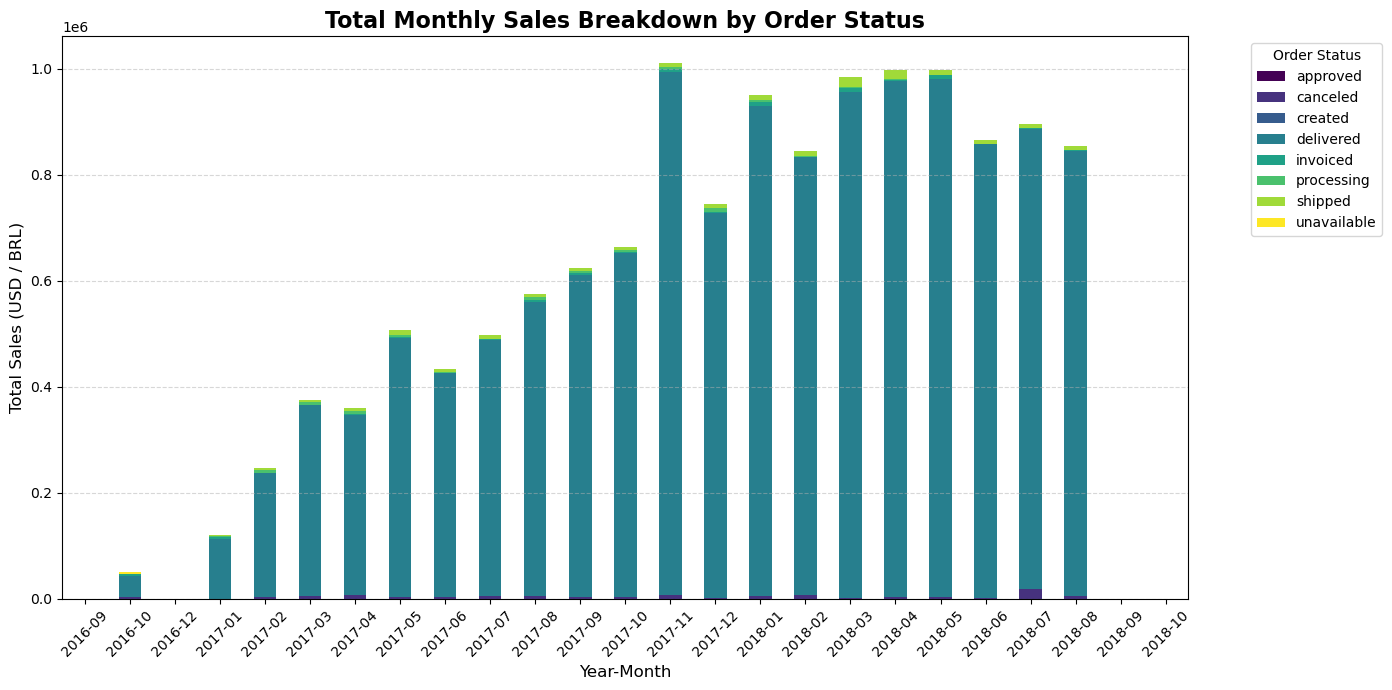

In [71]:


# Pivot the data to get months on the axis and statuses as columns
pivot_df = monthly_sales_status.pivot(index="year_month", columns="order_status", values="total_sales").fillna(0)

# Plot a stacked bar chart
pivot_df.plot(kind="bar", stacked=True, figsize=(14, 7), colormap="viridis")

plt.title("Total Monthly Sales Breakdown by Order Status", fontsize=16, fontweight='bold')
plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Total Sales (USD / BRL)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Order Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

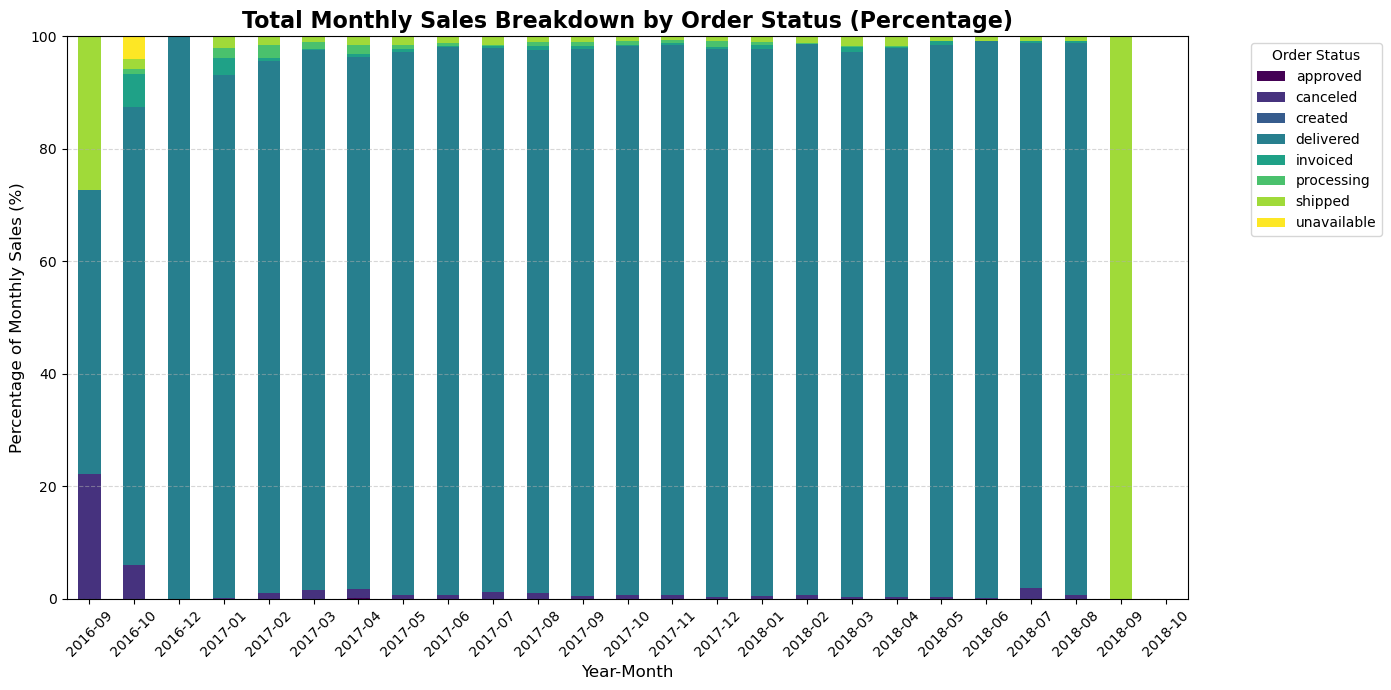

In [73]:
#100% stacked bar chart version (non-delivered statuses as percentages of total sales)

# 1. Pivot the data to get months on the axis and statuses as columns (Same as before)
pivot_df = monthly_sales_status.pivot(index="year_month", columns="order_status", values="total_sales").fillna(0)

# 2. Convert actual values into percentages for each individual month
# pivot_df.sum(axis=1) calculates the grand total sales for each month row.
# .div(..., axis=0) divides each status value in a month by that month's grand total.
pivot_df_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# 3. Plot the percentage-based stacked bar chart
pivot_df_pct.plot(kind="bar", stacked=True, figsize=(14, 7), colormap="viridis")

# Updated Title and Y-Label to reflect percentages
plt.title("Total Monthly Sales Breakdown by Order Status (Percentage)", fontsize=16, fontweight='bold')
plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Percentage of Monthly Sales (%)", fontsize=12) 
plt.ylim(0, 100) # Forces the Y-axis to bound perfectly between 0% and 100%

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Order Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

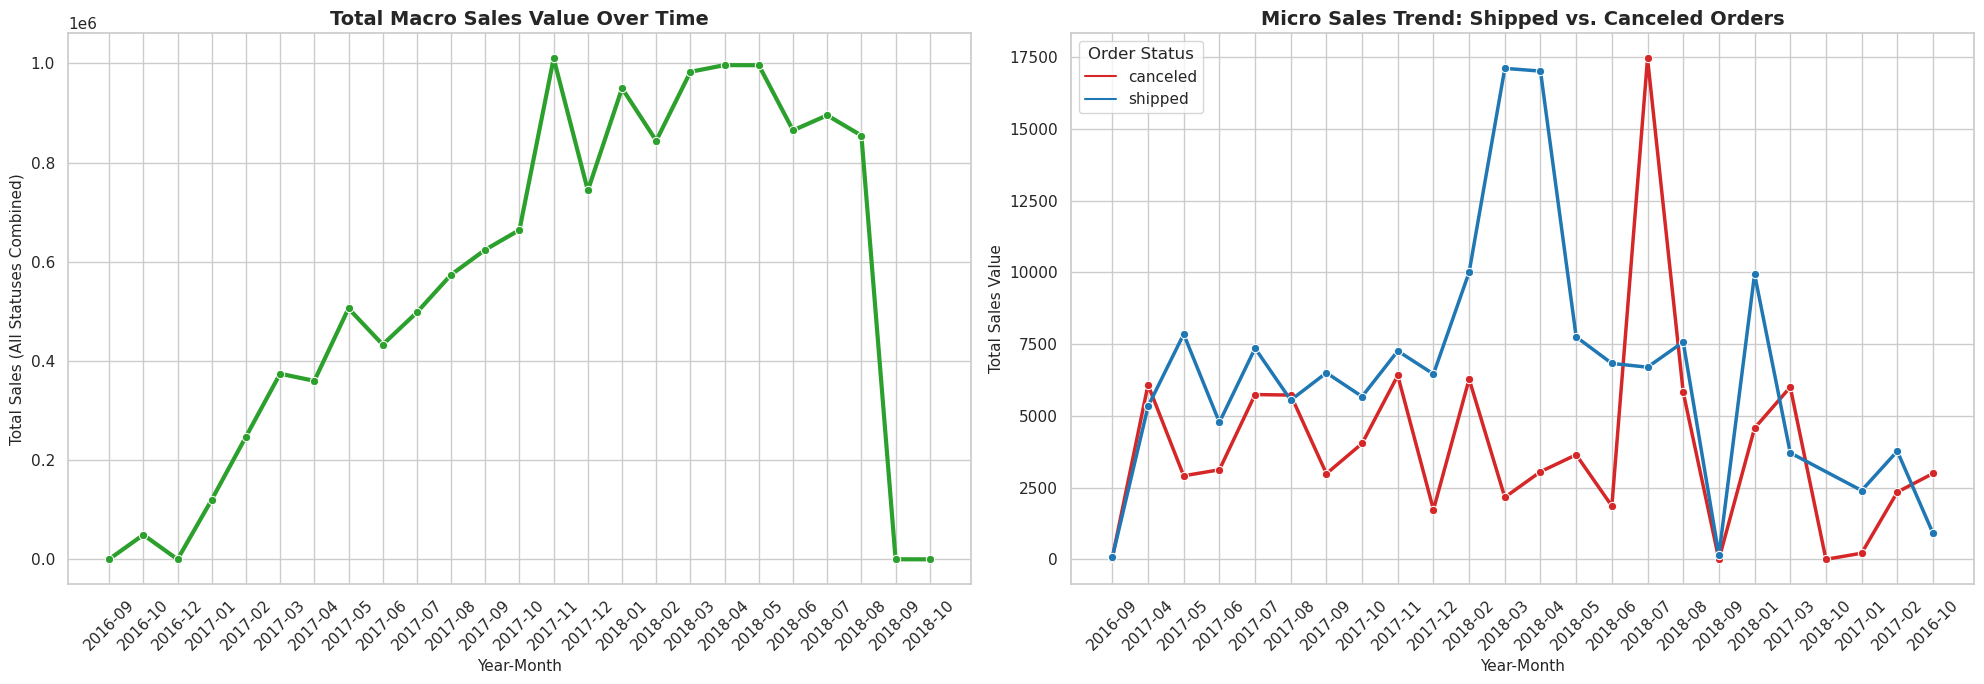

In [75]:

# --- STEP 1: PREPARE THE DATA ---

# Data for the Left Chart: Sum up ALL sales per month regardless of status
overall_monthly_sales = (
    monthly_sales_status.groupby("year_month")["total_sales"]
    .sum()
    .reset_index()
)

# Data for the Right Chart: Filter for only 'shipped' and 'canceled' (Same as before)
filtered_trends = monthly_sales_status[
    monthly_sales_status["order_status"].isin(["shipped", "canceled"])
]


# --- STEP 2: CREATE THE SIDE-BY-SIDE LAYOUT ---

# nrows=1, ncols=2 means 1 row, 2 charts next to each other
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(20, 7))
sns.set_theme(style="whitegrid")


# --- STEP 3: PLOT THE LEFT CHART (Total Company Sales) ---

sns.lineplot(
    data=overall_monthly_sales,
    x="year_month",
    y="total_sales",
    marker="o",
    linewidth=3,
    color="#2ca02c", # Elegant green for overall revenue growth
    ax=ax1          # Forces this plot to sit on the left axis
)
ax1.set_title("Total Macro Sales Value Over Time", fontsize=14, fontweight='bold')
ax1.set_xlabel("Year-Month", fontsize=11)
ax1.set_ylabel("Total Sales (All Statuses Combined)", fontsize=11)
ax1.tick_params(axis='x', labelrotation=45)


# --- STEP 4: PLOT THE RIGHT CHART (Shipped vs. Canceled) ---

sns.lineplot(
    data=filtered_trends, 
    x="year_month", 
    y="total_sales", 
    hue="order_status", 
    marker="o", 
    linewidth=2.5,
    palette={"shipped": "#1f77b4", "canceled": "#d62728"}, # Blue and Red
    ax=ax2          # Forces this plot to sit on the right axis
)
ax2.set_title("Micro Sales Trend: Shipped vs. Canceled Orders", fontsize=14, fontweight='bold')
ax2.set_xlabel("Year-Month", fontsize=11)
ax2.set_ylabel("Total Sales Value", fontsize=11)
ax2.tick_params(axis='x', labelrotation=45)
ax2.legend(title="Order Status", loc="upper left")


# --- STEP 5: DISPLAY ---

plt.tight_layout() # Automatically adjusts spacing so labels don't overlap
plt.show()

In [41]:
# English product categories by total sales
# Step A: Merge order items with products to get category names
items_with_cats = pd.merge(order_items, products, on="product_id", how="inner")

# Step B: Map Portuguese names to English categories
items_with_eng = pd.merge(items_with_cats, translation, on="product_category_name", how="left")

# Step C: Group by English category and sum total sales (price)
top_categories = (
    items_with_eng.groupby("product_category_name_english")["price"]
    .sum()
    .reset_index()
    .rename(columns={"price": "total_sales"})
    .sort_values(by="total_sales", ascending=False)
)

# Step D: Calculate the overall grand total sales for the entire company
grand_total_sales = order_items["price"].sum()

# Step E: Calculate the percentage of total sales for each category
# Formula: (Category Sales / Grand Total Sales) * 100
top_categories["pct_of_total_sales"] = ((top_categories["total_sales"] / grand_total_sales) * 100).round(2)

# Step F: Sort by revenue and grab the top 10
top_categories = top_categories.sort_values(by="total_sales", ascending=False)

top_categories_df = pd.DataFrame(top_categories)

print("--- Top 20 Categories by Sales ---")
display(top_categories_df.head(20))
print("\n--- Bottom 20 Categories by Sales ---")
display(top_categories_df.tail(20))

--- Top 20 Categories by Sales ---


,product_category_name_english,total_sales,pct_of_total_sales
43,health_beauty,1258681.34,9.26
70,watches_gifts,1205005.68,8.87
7,bed_bath_table,1036988.68,7.63
65,sports_leisure,988048.97,7.27
15,computers_accessories,911954.32,6.71
39,furniture_decor,729762.49,5.37
20,cool_stuff,635290.85,4.67
49,housewares,632248.66,4.65
5,auto,592720.11,4.36
42,garden_tools,485256.46,3.57



--- Bottom 20 Categories by Sales ---


,product_category_name_english,total_sales,pct_of_total_sales
30,fashion_male_clothing,10797.82,0.08
33,fashion_underwear_beach,9541.55,0.07
12,christmas_supplies,8800.82,0.06
67,tablets_printing_image,7528.41,0.06
13,cine_photo,6933.46,0.05
55,music,6034.35,0.04
25,dvds_blu_ray,5999.39,0.04
9,books_imported,4639.85,0.03
58,party_supplies,4485.18,0.03
41,furniture_mattress_and_upholstery,4368.08,0.03


In [56]:
# Step 1: Calculate total sales for every individual product
individual_product_sales = (
    order_items.groupby("product_id")["price"]
    .sum()
    .reset_index()
    .rename(columns={"price": "total_sales"})
)

# --- NEW STEP: Calculate the average review score for each individual product ---
# First, link order_items (to get product_id) with orders_reviews (to get review_score)
items_with_reviews = pd.merge(
    order_items[["product_id", "order_id"]], 
    orders_reviews[["order_id", "review_score"]], 
    on="order_id", 
    how="inner"
)

# Group by product_id and calculate the average score, rounded to 1 decimal place
product_avg_reviews = (
    items_with_reviews.groupby("product_id")["review_score"]
    .mean()
    .reset_index()
    .rename(columns={"review_score": "average_review_score"})
    .round(2)
)

# Step 2: Map the Portuguese category name from the PRODUCTS table to the sales data
sales_with_cats = pd.merge(
    individual_product_sales, 
    products[["product_id", "product_category_name"]], 
    on="product_id", 
    how="left"
)

# Step 3: Map the English translation from the TRANSLATION table
sales_with_eng = pd.merge(
    sales_with_cats, 
    translation, 
    on="product_category_name", 
    how="left"
)

# --- NEW STEP: Merge the average review score into our main pipeline ---
sales_with_reviews = pd.merge(
    sales_with_eng,
    product_avg_reviews,
    on="product_id",
    how="left"
)

# Step 4: Select and reorder the exact columns you asked for
final_table = sales_with_reviews[[
    "product_id", 
    "product_category_name_english", 
    "total_sales",
    "average_review_score"
]]

# Step 5: Calculate the overall grand total sales for the entire company
grand_total_sales = order_items["price"].sum()

# Step 6: Calculate the percentage of total sales for each category
# Formula: (Individual Product Sales / Grand Total Sales) * 100
final_table["pct_of_total_sales"] = ((final_table["total_sales"] / grand_total_sales) * 100).round(2)


# Step 7: Sort by total sales in descending order to get the top products
top_products_by_sales = final_table.sort_values(by="total_sales", ascending=False).reset_index(drop=True)

top_products_by_sales_df = pd.DataFrame(top_products_by_sales)
# Preview the top 10 individual products
display(top_products_by_sales_df.head(20))

,product_id,product_category_name_english,total_sales,average_review_score,pct_of_total_sales
0,bb50f2e236e5eea0100680137654686c,health_beauty,63885.00,4.22,0.47
1,6cdd53843498f92890544667809f1595,health_beauty,54730.20,4.32,0.40
2,d6160fb7873f184099d9bc95e30376af,computers,48899.34,4.57,0.36
3,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,47214.51,4.19,0.35
4,99a4788cb24856965c36a24e339b6058,bed_bath_table,43025.56,3.90,0.32
5,3dd2a17168ec895c781a9191c1e95ad7,computers_accessories,41082.60,4.21,0.30
6,25c38557cf793876c5abdd5931f922db,baby,38907.32,2.68,0.29
7,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,37733.90,4.56,0.28
8,53b36df67ebb7c41585e8d54d6772e08,watches_gifts,37683.42,4.19,0.28
9,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,37608.90,4.02,0.28


In [ ]:
# Step A: Aggregate total sales per unique product ID
product_sales = (
    order_items.groupby("product_id")["price"]
    .sum()
    .reset_index()
    .rename(columns={"price": "total_sales"})
    .sort_values(by="total_sales", ascending=False)
)
product_sales_df = pd.DataFrame(product_sales)


# Step B: Get all reviews tied to those top 20 products
# First, link those product IDs back to their order IDs
top_20_product_orders = pd.merge(product_sales, order_items[["product_id", "order_id"]], on="product_id", how="inner")

# Next, pull the specific review messages for those orders
top_20_products_with_reviews = pd.merge(
    top_20_product_orders, 
    orders_reviews[["order_id", "review_score", "review_comment_message"]], 
    on="order_id", 
    how="inner"
)

# Clean up to display product_id alongside its total revenue and its textual review list
top_20_reviews_table = top_20_products_with_reviews[["product_id", "total_sales", "review_score", "review_comment_message"]]

print("\n--- Top 20 Products & Individual Reviews ---")
display(product_sales_df.head(20))
print(top_20_reviews_table.head())


--- Top 20 Products & Individual Reviews ---


,product_id,total_sales
24086,bb50f2e236e5eea0100680137654686c,63885.00
14068,6cdd53843498f92890544667809f1595,54730.20
27613,d6160fb7873f184099d9bc95e30376af,48899.34
27039,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51
19742,99a4788cb24856965c36a24e339b6058,43025.56
8051,3dd2a17168ec895c781a9191c1e95ad7,41082.60
4996,25c38557cf793876c5abdd5931f922db,38907.32
12351,5f504b3a1c75b73d6151be81eb05bdc9,37733.90
10867,53b36df67ebb7c41585e8d54d6772e08,37683.42
22112,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90


                         product_id  total_sales  review_score  \
0  bb50f2e236e5eea0100680137654686c      63885.0             1   
1  bb50f2e236e5eea0100680137654686c      63885.0             5   
2  bb50f2e236e5eea0100680137654686c      63885.0             1   
3  bb50f2e236e5eea0100680137654686c      63885.0             1   
4  bb50f2e236e5eea0100680137654686c      63885.0             5   

                              review_comment_message  
0                                                NaN  
1                                                NaN  
2  Estou esperando o meu produto já tem mais de 1...  
3  Não recebi a mercadoria e não tive retorno do ...  
4  Os produtos chegaram conforme o prometido de q...  


---
# Staging Layer — What Was Done and Why

## What is the Staging Layer?

After the raw CSV data was loaded into BigQuery (`kaggle_data` dataset), we created a **staging layer** using dbt. Think of staging like unpacking delivery boxes and relabelling everything clearly before you start cooking — you are not changing the ingredients, just making them easier to work with.

The staging layer lives in the `olist_dev_staging` BigQuery dataset as **views** (not tables — a view is just a saved SQL query that runs fresh each time you query it).

## What exactly was changed?

### 1. Column renaming
Long, inconsistent column names were shortened and standardised:
- `customer_zip_code_prefix` → `zip_code_prefix`
- `seller_zip_code_prefix` → `zip_code_prefix`
- `geolocation_lat` → `lat`, `geolocation_lng` → `lng`
- `product_name_lenght` → `name_length` *(fixing the typo in the original data)*

### 2. Data type casting
The raw data stores everything as text. We cast columns to their proper types:
- Timestamp columns (e.g. `order_purchase_timestamp`) → `TIMESTAMP` so we can do date arithmetic
- `price`, `freight_value`, `payment_value` → `FLOAT64` (decimal numbers)
- `review_score`, dimensions, weight → `INT64` (whole numbers)
- Zip code prefixes → `STRING` (to preserve leading zeros)

### 3. Null standardisation
Empty strings in the reviews table (`review_comment_title`, `review_comment_message`) were converted to proper `NULL` values. This matters because an empty string and a missing value look the same to a human but behave differently in SQL queries.

### What was NOT changed
- **No rows were removed** — all records pass through staging unchanged
- **No tables were joined** — each staging model covers exactly one source table
- **No business calculations** — no totals, averages, or derived metrics

The staging layer is the foundation that all downstream layers (data quality and star schema) rely on.

In [ ]:
# Connect to BigQuery and preview the staging views
from google.cloud import bigquery

client = bigquery.Client(project='our-project-93971')

staging_tables = [
    'stg_orders', 'stg_customers', 'stg_order_items',
    'stg_order_payments', 'stg_order_reviews', 'stg_products',
    'stg_sellers', 'stg_geolocation', 'stg_category_name_translation'
]

print('Staging layer — row counts (should match raw CSV counts):')
for t in staging_tables:
    result = client.query(f'SELECT COUNT(*) as cnt FROM `our-project-93971.olist_dev_staging.{t}`').result()
    cnt = list(result)[0].cnt
    print(f'  {t}: {cnt:,} rows')

In [ ]:
# Preview stg_orders to see renamed + cast columns vs raw
import pandas as pd

stg_orders_preview = client.query(
    'SELECT order_id, customer_id, order_status, purchase_at, delivered_customer_at '
    'FROM `our-project-93971.olist_dev_staging.stg_orders` LIMIT 5'
).to_dataframe()

print('stg_orders — cast timestamps and renamed columns:')
display(stg_orders_preview)

---
# Data Quality Layer — What Was Found and Why It Matters

## What is the Data Quality Layer?

After staging, we ran each table through a set of **data quality checks**. Think of this like a quality inspector on a production line — every item passes through, and anything that doesn't meet the standard gets set aside with a label explaining what's wrong.

The data quality layer lives in the `olist_dev_data_quality` BigQuery dataset as **tables**. Each table only stores the **problematic rows** — if a table is empty, that source is clean.

## What checks were run?

For each source table, we checked for:
- **Null values** in columns that should never be empty (e.g. order_id, customer_id)
- **Invalid values** that don't match the expected range or list (e.g. review scores outside 1–5, unknown payment types)
- **Logical inconsistencies** (e.g. a delivery date that is earlier than the purchase date — physically impossible)
- **Out-of-range data** (e.g. GPS coordinates outside Brazil's geographic boundaries)

Each flagged row has:
- A `TRUE/FALSE` column for every check (e.g. `null_category_name = TRUE`)
- An `issues` column that lists all the problems on that row in plain text

## What did we find?

| Table | Flagged rows | Main issues |
|---|---:|---|
| orders | 0 | Clean ✅ |
| customers | 0 | Clean ✅ |
| order_items | 0 | Clean ✅ |
| order_payments | 9 | Zero/negative payment values, unknown payment type |
| order_reviews | 0 | Clean ✅ |
| products | 611 | 609 products missing category name, 2 missing dimensions |
| sellers | 0 | Clean ✅ |
| geolocation | 42 | Coordinates outside Brazil's bounds |
| category_name_translation | 0 | Clean ✅ |

**The most significant finding:** 609 products (1.85% of the catalogue) have no category name in the raw data. This means they cannot be matched to an English category name either. These products are **excluded from the clean star schema** so they don't pollute category-level analysis.

In [ ]:
# Query the data quality layer — see actual flagged rows
dq_tables = [
    'dq_orders', 'dq_customers', 'dq_order_items', 'dq_order_payments',
    'dq_order_reviews', 'dq_products', 'dq_sellers', 'dq_geolocation',
    'dq_category_name_translation'
]

print('Data Quality layer — flagged row counts:')
for t in dq_tables:
    result = client.query(
        f'SELECT COUNT(*) as cnt FROM `our-project-93971.olist_dev_data_quality.{t}`'
    ).result()
    cnt = list(result)[0].cnt
    status = '✅ Clean' if cnt == 0 else f'⚠️  {cnt:,} flagged rows'
    print(f'  {t}: {status}')

In [ ]:
# Drill into dq_products — what issues do products have?
dq_products_df = client.query(
    'SELECT issues, COUNT(*) as count '
    'FROM `our-project-93971.olist_dev_data_quality.dq_products` '
    'GROUP BY issues ORDER BY count DESC'
).to_dataframe()

print('Product data quality issues breakdown:')
display(dq_products_df)

In [ ]:
# Drill into dq_geolocation — out-of-range coordinates
dq_geo_df = client.query(
    'SELECT zip_code_prefix, lat, lng, issues '
    'FROM `our-project-93971.olist_dev_data_quality.dq_geolocation` '
    'LIMIT 10'
).to_dataframe()

print('Geolocation issues — sample of out-of-range coordinates:')
display(dq_geo_df)

In [ ]:
# Drill into dq_order_payments — payment value issues
dq_payments_df = client.query(
    'SELECT order_id, payment_sequential, issues '
    'FROM `our-project-93971.olist_dev_data_quality.dq_order_payments`'
).to_dataframe()

print('Payment data quality issues:')
display(dq_payments_df)

---
# Summary — What the Pipeline Produces

After running `dbt run` and `dbt test`, the pipeline creates three datasets in BigQuery:

| BigQuery dataset | What's inside | Purpose |
|---|---|---|
| `olist_dev_staging` | 9 views (stg_*) | Clean, consistently typed versions of raw tables |
| `olist_dev_data_quality` | 9 tables (dq_*) | Flagged problem rows — empty = clean |
| `olist_dev_star` | 6 tables (fact_* + dim_*) | Clean, analysis-ready star schema |

The star schema tables (`fact_order_items`, `fact_orders`, `dim_customers`, `dim_products`, `dim_sellers`, `dim_dates`) are what you query for business analysis. All problematic rows from the DQ layer are excluded.